<a href="https://colab.research.google.com/github/raja-kumar-jha/pytorch-deep-learning-journey/blob/main/notebooks/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Workflow

Let's explore an example of PyTorch ene-to-end workflow

**what were covering :**

1. data (prepare and load)
2. build model
3. fitting the model to data (training)
4. making predictions and evaluting a model (inference)
5. putting it all together

In [1]:
# import torch
import torch
# import nn module
from  torch import nn
# import matplot for visualization
import matplotlib.pyplot as plt
# import seaborn for advance visualization
import seaborn as sns

# check the version of torch
print(torch.__version__)

2.11.0+cpu


## 1. Data preparing and loading

Data can be anything.. in machine learning.

* Excel/Google sheet
* Image of any kind
* Video(youtube has a lots of data..)
* Audio like songs or podcasts and many more things
* DNA
* Text

Machine learing is a game of two parts:
1. Get data into numerical fashion
2. Build model to learn patterns in that numerical data

In [2]:
# Create *known* parameters
weight = 0.6 # weight parameter
bias = 0.4 # bias(y-intercept) parameter

# creating a simple dataset using arange
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1) # This is the feature(independent variable)
y = weight * X + bias # This is the label(dependent variable)

"""
Here I have created the data, the X is basically feature of my dataset and the y is the label for my data. Now
the goal will be to predict the value of y(our true label) from the model we gonna implement in the next code sell.
"""

X[:10], y[:10] # Here we are searching for first rows of our feature and our true label

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.4000],
         [0.4120],
         [0.4240],
         [0.4360],
         [0.4480],
         [0.4600],
         [0.4720],
         [0.4840],
         [0.4960],
         [0.5080]]))

In [3]:
len(X), len(y) # here we are checking how many rows we have in total -> means how many data samples we have


(50, 50)

### Splitting data into training and test sets

In [4]:
# Create a train/test split
train_split = int(0.8*len(X)) # Here we are assigning 80% criteria
X_train, y_train = X[:train_split], y[:train_split] # This the tarining sample fop the learning of our model
X_test, y_test = X[train_split:], y[train_split:] # This the dataset in which our model will be evaluated

len(X_train), len(y_train), len(X_test), len(y_test) # Here we can see how many samples are used for train and test

(40, 40, 10, 10)

In [5]:
# Here I am defining a function to analysis the data and their prediction
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):

  """
  Plot training data , test data and compares predictions.
  """
  plt.figure(figsize=(6, 5))
  # plot training data in blue
  plt.scatter(train_data, train_labels, c='b', s=4, label="Training data")

  # plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  # Are there predictions?
  if predictions is not None:
    # plot the predictions if they exist
    plt.scatter(test_data, predictions, c='r', s=4, label="Predictions")
  # show the legend
  plt.legend(prop={"size":12});

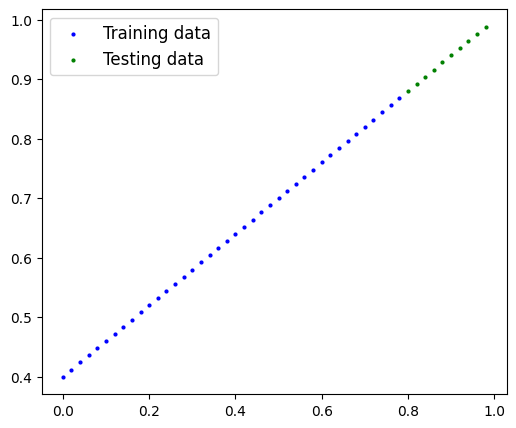

In [6]:
plot_predictions();

## 2. Building model
My first PyTorch model!

What our model does:
* Start with random values(weight & bias)
* Look at the training data and adjust the random values to better represent (or get closer to) the ideal values (the weight and bias values we used to create the data)

How does it do so?

Through two main algorithm:
1. Gradient descent
2. Backpropagation

In [7]:
# Here we are definig the model we gonna use to build the model
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()

    # Initialize model parameters(weights and bias)
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True, dtype= torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True, dtype=torch.float))

  # Forword method to define the computation in the model
  def forward(self, x:torch.Tensor) -> torch.Tensor: #<- "x" is the input data
    return self.weights * x + bias # this is the linear regression formula


### PyTorch model building essentials

* torch.nn - contains all of the buildings for comutational graphs(a nural network can be considered a computational graph)
* torch.nn.Parameter - what parameters should our mmodel try and learn, often a PyTorch layer from torch.nn will set these for use
* torch.nn.Module - The base class for all nural network modules, if we subclass it, we should overwrite forword()
* torch.optim - this is where the optimizers in PyTorch live, they will help with gradient decent
* def forword() - all nn.Model subclass require us to overwrite forword(), this method defines what happens in forword() comutation

### checking the contents of the Pytorch model

Now we've created a model, let's see what's inside..

So we can check our model parammeters or what's inside our model using .parameters().

In [8]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module)

Model_0 = LinearRegressionModel()

# check out the parameter
list(Model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [9]:
# List named paramers
Model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making prediction using `torch.inference_mode()`

To check our model's predictive power, let's see how well it predicts `y_test` based on `X_test`.

When we pass data through our model, it's going to run it through the forward() method.

In [10]:
# Make predictions with model
with torch.inference_mode():
  y_preds = Model_0(X_test)

y_preds

tensor([[0.6694],
        [0.6761],
        [0.6828],
        [0.6896],
        [0.6963],
        [0.7030],
        [0.7098],
        [0.7165],
        [0.7232],
        [0.7300]])

In [11]:
y_test

tensor([[0.8800],
        [0.8920],
        [0.9040],
        [0.9160],
        [0.9280],
        [0.9400],
        [0.9520],
        [0.9640],
        [0.9760],
        [0.9880]])

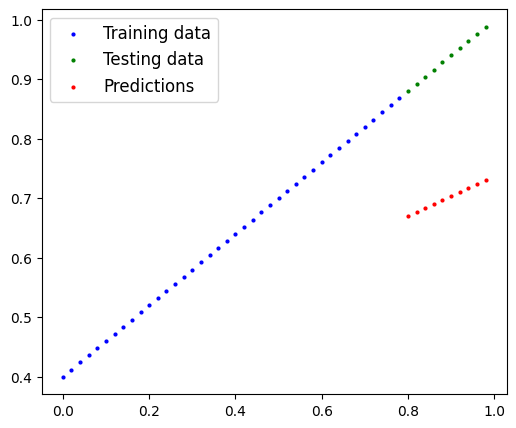

In [12]:
plot_predictions(predictions=y_preds)

## Train model
The whole idea of training is for a model to move from some "unknown" parameters(these may be random) to **Known** parameters.

Or in other words from a poor representation of the data to a better representation of data.

One way to measure how poor or how wrong your models predictions are is to use a loss function.

* Note: Loss function may also be called cost function or criterion in different areas.

Things we need to train:
* Loss function: A function to measure how wrong our model's predictions are to the ideal outputs. Lower the loss better the result.

* Optimizer: An optimisizer updates the model's parameters to minimize the loss.

for exam, suppose our model has:
` w = 5`

The loss function tells us that the corrent value of w isn't good.

The optimizer might change it

In [13]:
Model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [14]:
# Setup a loss function
loss_fn = nn.L1Loss()

# Setup an optimizer(Stochastic gradient descent)
optimizer = torch.optim.SGD(params=Model_0.parameters(),
                            lr=0.01) # lr = learnong rate -> possibly the most important hyperparamets

### Building a training loop (and a testing loop) in PyTorch

A couple of things we need in a training loop:

0. Loop through the data
1. Forword pass (this involves data moving through our model's `forward()` functions) to make predictions on data - also called forward propagation.
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwords through the network to calculate the gradients of each of the parameters of our model with respect to the loss
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss




In [22]:
torch.manual_seed(42)
# An epoch is one loop through the data
epochs = 1

# 0. Loop through the data
for epoch in range(epochs):
  # set the model top training model
  Model_0.train() # train mode in PyTorch sets all parametes that require gradients to require gradients

  #1. Forword pass
  y_pred = Model_0(X_train)

  # 2. calculate the loss
  loss = loss_fn(y_pred, y_train)
  print(f'Loss: {loss}')

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Perform backpropagation on the loss with reqpect to the parameters of the model
  loss.backward()

  # 5. step the optimizer (perform gradient descent)
  optimizer.step()

  Model_0.eval() # turns off gradient tracking

Loss: 0.09812777489423752


In [23]:
Model_0.state_dict()

OrderedDict([('weights', tensor([0.3523])), ('bias', tensor([0.1288]))])

In [17]:
weight, bias

(0.6, 0.4)